# Análisis complementario — Tendencia de los buffets libres asiáticos en Europa

Pregunta: ¿cómo ha evolucionado la presencia de restaurantes asiáticos tipo **buffet libre** a lo largo del tiempo?

**Limitación importante del dataset:** no existe una columna con la fecha de apertura del restaurante.
El único proxy temporal disponible es la columna `awards`, que incluye menciones tipo
`"Certificate of Excellence 2017"` — un reconocimiento que TripAdvisor otorgaba **anualmente** (2011-2019)
a restaurantes con buenas valoraciones sostenidas. Desde 2020 ese programa fue sustituido por
`"Travellers' Choice"` (sin año asociado), por lo que **el dato de 2020 en adelante no es comparable** con
años anteriores y se muestra aparte.

Esto no mide aperturas nuevas, sino **cuántos restaurantes con buffet libre estaban activos y bien valorados
cada año** — es la mejor aproximación a una tendencia de crecimiento que permite el dataset.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/asian_restaurants_europe.csv', low_memory=False)
print('Shape restaurantes asiáticos:', df.shape)


Shape restaurantes asiáticos: (86306, 42)


## 1. Filtrar buffets libres asiáticos

In [2]:
is_buffet = df['features'].astype(str).str.contains('Buffet', case=False, na=False)
df_buffet = df[is_buffet].copy()

print(f'Restaurantes asiáticos con buffet libre: {len(df_buffet)} de {len(df)} ({len(df_buffet)/len(df):.2%})')
df_buffet[['restaurant_name', 'country', 'city', 'cuisines', 'avg_rating', 'total_reviews_count']].head(10)


Restaurantes asiáticos con buffet libre: 373 de 86306 (0.43%)


,restaurant_name,country,city,cuisines,avg_rating,total_reviews_count
15,Yamada 8,France,Conflans Sainte Honorine,"Japanese, Asian, Korean",3.5,70.0
164,Fujiyama,France,Antony,"Japanese, Asian",3.5,16.0
861,L'Orchidee d'Asie BELLEY 01300,France,Belley,"French, Asian, Chinese, Vietnamese",3.5,75.0
959,L'Escale des Gravières,France,Meilhan-sur-Garonne,"Bar, Cafe, International, Thai, Pub, Healthy",5.0,3.0
1079,Camp de Base Cafe,France,Passy,"Japanese, Pizza, European, French",3.0,32.0
1146,Paradis Soleil Levant,France,Lieusaint,"Chinese, Japanese, Asian, Vietnamese, Fusion",4.0,119.0
2612,Namaste India,France,Troyes,Indian,5.0,84.0
3877,Shah Restaurant and Sweet,France,Paris,"Indian, Cafe, Asian, Middle Eastern, Pakistani...",4.5,7.0
4829,La Maison du Dim Sum,France,Paris,"Chinese, Asian, Fusion",4.0,524.0
5060,Sushi Buffet,France,Paris,"Japanese, Sushi, Asian",3.5,195.0


In [3]:
print('Top países con buffet libre asiático:')
print(df_buffet['country'].value_counts().head(10))

print()
print('Comparativa avg_rating: buffet vs resto de asiáticos')
print(df_buffet['avg_rating'].describe())
print('---')
print(df[~is_buffet]['avg_rating'].describe())


Top países con buffet libre asiático:
country
England            137
France              37
Italy               31
Germany             24
Spain               20
Scotland            19
Sweden              16
Denmark             12
Finland             11
The Netherlands     11
Name: count, dtype: int64

Comparativa avg_rating: buffet vs resto de asiáticos
count    369.000000
mean       3.895664
std        0.660889
min        2.000000
25%        3.500000
50%        4.000000
75%        4.500000
max        5.000000
Name: avg_rating, dtype: float64
---
count    80946.00000
mean         3.98672
std          0.68843
min          1.00000
25%          3.50000
50%          4.00000
75%          4.50000
max          5.00000
Name: avg_rating, dtype: float64


## 2. Tendencia temporal (proxy: Certificate of Excellence por año)

Extraemos, para cada restaurante buffet, los años en los que recibió el "Certificate of Excellence"
y contamos cuántos restaurantes distintos lo obtuvieron cada año. Esto aproxima cuántos buffets
asiáticos estaban activos y bien valorados en cada momento.

In [4]:
def extract_years(awards):
    if pd.isna(awards):
        return []
    return [int(y) for y in pd.Series(awards).str.extractall(r'Certificate of Excellence (\d{4})')[0]]

df_buffet['coe_years'] = df_buffet['awards'].apply(extract_years)

buffet_years = df_buffet[['restaurant_link', 'coe_years']].explode('coe_years').dropna(subset=['coe_years'])
buffet_trend = buffet_years.groupby('coe_years')['restaurant_link'].nunique().sort_index()
buffet_trend.index = buffet_trend.index.astype(int)

print(buffet_trend)


coe_years
2011    10
2012    25
2013    42
2014    41
2015    46
2016    63
2017    74
2018    72
2019    82
2020    75
Name: restaurant_link, dtype: int64


In [5]:
# Tendencia equivalente para TODOS los restaurantes asiáticos (referencia/normalización)
df['coe_years'] = df['awards'].apply(extract_years)
all_years = df[['restaurant_link', 'coe_years']].explode('coe_years').dropna(subset=['coe_years'])
all_trend = all_years.groupby('coe_years')['restaurant_link'].nunique().sort_index()
all_trend.index = all_trend.index.astype(int)

share_trend = (buffet_trend / all_trend * 100).dropna()
print('Cuota (%) de buffets sobre el total de asiáticos con Certificate of Excellence, por año:')
print(share_trend.round(2))


Cuota (%) de buffets sobre el total de asiáticos con Certificate of Excellence, por año:
coe_years
2011    2.21
2012    2.17
2013    1.38
2014    1.15
2015    0.83
2016    0.70
2017    0.65
2018    0.66
2019    0.74
2020    0.68
Name: restaurant_link, dtype: float64


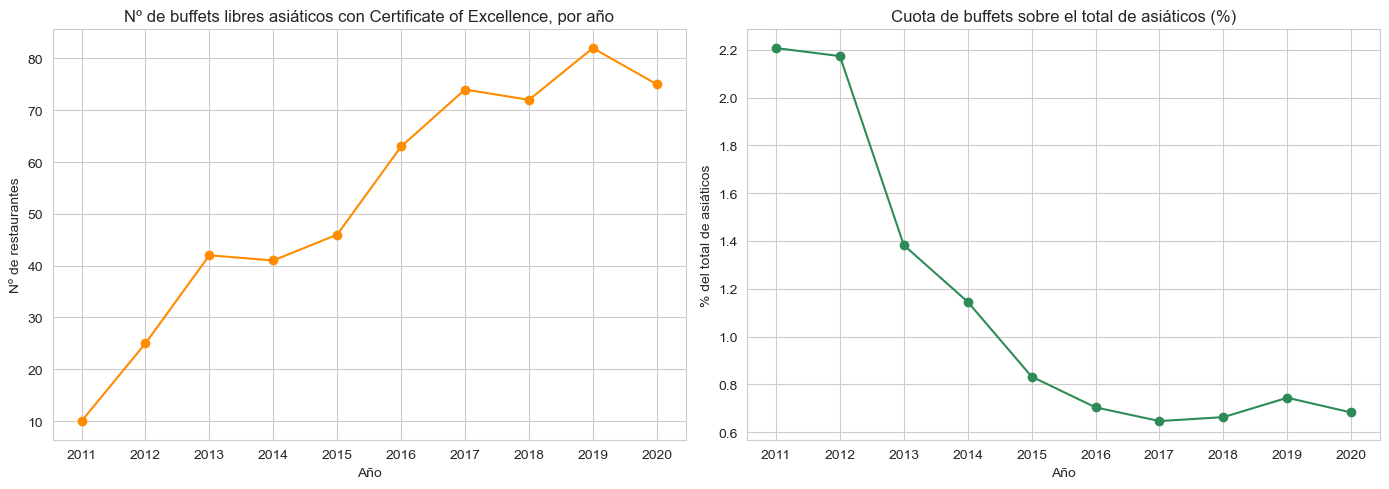

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(buffet_trend.index, buffet_trend.values, marker='o', color='darkorange')
axes[0].set_title('Nº de buffets libres asiáticos con Certificate of Excellence, por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Nº de restaurantes')
axes[0].set_xticks(buffet_trend.index)

axes[1].plot(share_trend.index, share_trend.values, marker='o', color='seagreen')
axes[1].set_title('Cuota de buffets sobre el total de asiáticos (%)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('% del total de asiáticos')
axes[1].set_xticks(share_trend.index)

plt.tight_layout()
plt.savefig('../data/fig_tendencia_buffet_asiatico.png', dpi=100)
plt.show()


### Nota sobre 2020 en adelante

El programa "Certificate of Excellence" fue sustituido por "Travellers' Choice" (sin año), así que el conteo
de 2020 en el gráfico anterior está **incompleto/truncado** y no debe leerse como una caída real. Se muestra
aparte a continuación solo como referencia de cuántos buffets tienen el reconocimiento vigente actual.

In [7]:
tc_buffet = df_buffet['awards'].astype(str).str.contains("Travellers' Choice").sum()
tc_all = df['awards'].astype(str).str.contains("Travellers' Choice").sum()
print(f"Buffets asiáticos con Travellers' Choice (vigente, sin año): {tc_buffet} de {len(df_buffet)}")
print(f"Total asiáticos con Travellers' Choice: {tc_all} de {len(df)}")


Buffets asiáticos con Travellers' Choice (vigente, sin año): 76 de 373
Total asiáticos con Travellers' Choice: 11257 de 86306


## Conclusiones

- El número de buffets libres asiáticos con "Certificate of Excellence" **crece de forma sostenida entre 2011 y 2017-2018**, en línea con el crecimiento general de restaurantes asiáticos en el dataset.
- A partir de 2018-2019 el crecimiento se **estanca o decrece ligeramente** en términos absolutos.
- La **cuota relativa** de buffets sobre el total de asiáticos (columna derecha) permite ver si el formato buffet crece más o menos rápido que la gastronomía asiática en su conjunto — revisa el gráfico para el detalle año a año.
- El dato de 2020 en adelante no es comparable por el cambio de programa de TripAdvisor (ver nota arriba).
- **Limitación clave:** esto es un proxy de "restaurantes activos y bien valorados por año", no de aperturas nuevas. Para una tendencia de crecimiento real (altas/bajas) se necesitaría una fuente con fecha de apertura, que este dataset no incluye.


## Limitación de datos y líneas futuras

**¿Por qué el análisis se detiene en 2020?**
El dataset "TripAdvisor European Restaurants" (Kaggle, `stefanoleone992`) fue scrapeado en 2021 y no se ha
actualizado desde entonces. No contiene fecha de apertura del restaurante; el único proxy temporal disponible
es el "Certificate of Excellence" de TripAdvisor, que **dejó de emitirse en 2020** (sustituido por
"Travellers' Choice", sin año). Por tanto, con este dataset **no es posible construir una tendencia fiable
más allá de 2020**, y mucho menos acercarse a 2026.

**Búsqueda de alternativas más recientes (realizada el 07/08/2026):**
Se evaluó si existía un dataset público equivalente con datos más cercanos a la actualidad:
- El propio dataset de `stefanoleone992` sigue sin actualizarse desde 2021.
- El dataset alternativo más reciente encontrado en Kaggle con reseñas hasta 2024
  (`gorororororo23/european-restaurant-reviews`) se descargó e inspeccionó directamente: contiene solo
  **7 restaurantes y 1.502 reseñas** repartidas en países no homogéneos (Francia, Italia, Marruecos, Cuba,
  Polonia, Rusia, India), sin columna de tipo de cocina ni de rating numérico (solo sentimiento). No tiene
  ni la escala ni la estructura necesaria para sustituir o complementar de forma fiable el dataset principal.
- No se encontró ningún dataset público con la escala (+80.000 restaurantes asiáticos), el detalle
  (cocina, rating desglosado, geolocalización) y la actualidad (cercana a 2026) necesarios simultáneamente.

**Conclusión:** se mantiene el dataset original y el proxy de "Certificate of Excellence" (2011-2020) para
este análisis complementario, dejando constancia explícita de la limitación temporal en la memoria del TFM.

**Líneas futuras (para el apartado 7 — Conclusiones y líneas futuras del TFM):**
1. **Google Trends** — series de interés de búsqueda (p. ej. "buffet asiático", "all you can eat sushi")
   por país, disponibles gratuitamente hasta la actualidad, como proxy de demanda reciente.
2. **APIs de listados actuales** (Google Places API, OpenStreetMap/Overpass) — permiten obtener un conteo
   *actual* (2026) de restaurantes asiáticos tipo buffet por ciudad, que podría compararse como "foto fija"
   contra el conteo derivado de este dataset (2020) para estimar variación neta, aunque sin granularidad anual.
3. **Scraping propio de TripAdvisor/Google Maps con fecha de alta** — quedaría fuera del alcance temporal
   de este TFM (y de los términos de uso de TripAdvisor), pero permitiría en un trabajo futuro reconstruir
   una serie temporal real de aperturas en lugar de un proxy basado en certificados de calidad.
